# Figures of chapter 4

In [1]:
# figures settings

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

## personal settings
band_size = (10, 6)
trim_size = (8, 4)
dpi = 196
label = 16
subtitle = 12
line_width = 1.5
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
          "axes.titlesize": 20, "axes.labelsize": label, "xtick.labelsize": 14,
          "ytick.labelsize": 14, "legend.fontsize": 14, "figure.facecolor": "w",
          "lines.linewidth": line_width, "lines.solid_capstyle": "round",
          "lines.dash_capstyle": "round", "lines.solid_joinstyle": "round",
          "lines.dash_joinstyle": "round"}
plt.rcParams.update(params)
colors = ["#1478E1", "#19A0A0", "#FA8200", "#8C64E1"]
blue, teal, orange, violet = colors
grey = "#787878"
dark_grey = "#3C3C3C"
tab_style = {"boxstyle": "round", "facecolor": plt.rcParams["axes.facecolor"],
             "edgecolor": plt.rcParams["legend.edgecolor"],
             "alpha": plt.rcParams["legend.framealpha"]}

## output folder
output_directory = Path("figures_ch4") if Path("figures_ch4").is_dir() else Path(".")


## 4.1 Band subspace

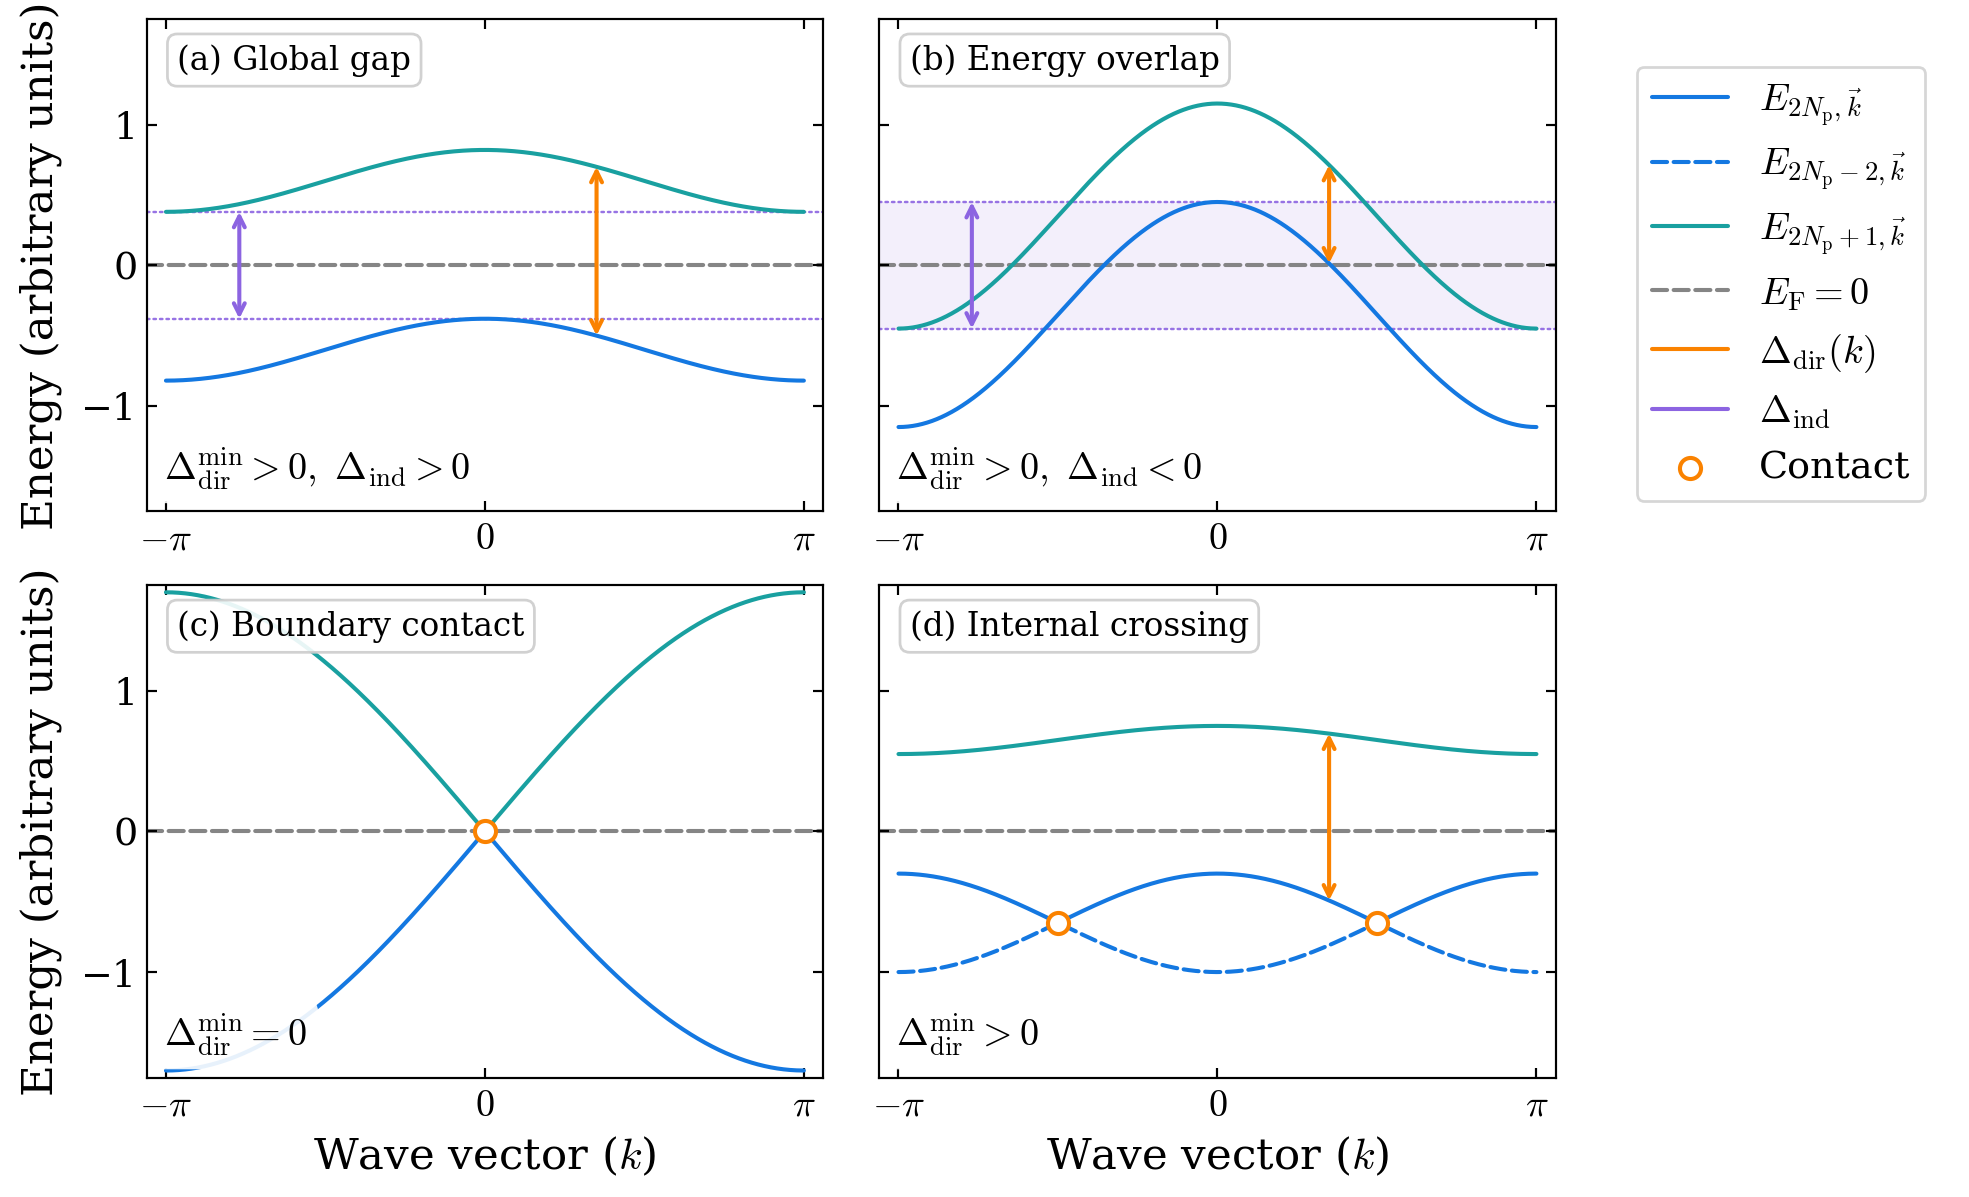

In [ ]:
## bands and labels
k = np.linspace(-np.pi, np.pi, 1201)
c = np.cos(k)
models = [(-0.60 + 0.22*c, 0.60 + 0.22*c),
          (-0.35 + 0.80*c, 0.35 + 0.80*c),
          (-0.85*np.sqrt(2*(1-c)), 0.85*np.sqrt(2*(1-c))),
          (-0.65 + 0.35*np.abs(c), 0.65 + 0.10*c)]
titles = ["(a) Global gap", "(b) Energy overlap", "(c) Boundary contact", "(d) Internal crossing"]
conditions = [r"$\Delta_{\rm dir}^{\rm min}>0,\ \Delta_{\rm ind}>0$",
              r"$\Delta_{\rm dir}^{\rm min}>0,\ \Delta_{\rm ind}<0$",
              r"$\Delta_{\rm dir}^{\rm min}=0$", r"$\Delta_{\rm dir}^{\rm min}>0$"]
box = dict(boxstyle="round", facecolor="white", alpha=0.9)

def gap_arrow(ax, x, low, high, color):
    ax.annotate("", (x, high), (x, low), zorder=6, arrowprops=dict(
        arrowstyle="<->", color=color, lw=line_width, shrinkA=0, shrinkB=0))

## layout
fig = plt.figure(figsize=band_size, dpi=dpi)
gs = fig.add_gridspec(2, 3, width_ratios=(1, 1, 0.5), left=0.08, right=1,
                     bottom=0.1, top=1, wspace=0.10, hspace=0.15)
axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(2)])
for ax in axes.flat[1:]: ax.sharey(axes[0, 0])

for i, (ax, (lower, upper)) in enumerate(zip(axes.flat, models)):
    ax.set(xlim=(-1.06*np.pi, 1.06*np.pi), ylim=(-1.75, 1.75), yticks=[-1, 0, 1])
    ax.set_xticks([-np.pi, 0, np.pi], [r"$-\pi$", r"$0$", r"$\pi$"])
    ax.tick_params(direction="in", top=True, right=True, labelleft=(i % 2 == 0))
    if i > 1: ax.set_xlabel(r"Wave vector ($k$)", labelpad=4)
    if i % 2 == 0: ax.set_ylabel("Energy (arbitrary units)", labelpad=7)

    ef = ax.axhline(0, color=grey, ls="--", alpha=0.9, zorder=0)
    lo, = ax.plot(k, lower, color=blue, zorder=4)
    hi, = ax.plot(k, upper, color=teal, zorder=4)
    if i == 3: inner, = ax.plot(k, -0.65-0.35*np.abs(c), color=blue, ls="--", zorder=4)
    ax.set_title(titles[i], loc="left", x=0.045, y=0.95, pad=0, va="top", fontsize=subtitle,
                 bbox=dict(box, edgecolor=plt.rcParams["legend.edgecolor"]), zorder=10)
    ax.text(0.025, 0.04, conditions[i], transform=ax.transAxes, va="bottom",
            fontsize=params["xtick.labelsize"], bbox=dict(box, edgecolor="none"), zorder=10)

    if i != 2:
        x = 0.35*np.pi
        gap_arrow(ax, x, np.interp(x, k, lower), np.interp(x, k, upper), orange)
    if i < 2:
        umin, lmax = upper.min(), lower.max()
        for e in (umin, lmax): ax.axhline(e, color=violet, lw=0.9, ls=":", alpha=0.9, zorder=1)
        if i == 1: ax.axhspan(umin, lmax, facecolor=violet, alpha=0.1, zorder=-1)
        gap_arrow(ax, -0.77*np.pi, lmax, umin, violet)
    if i > 1:
        ck, ce = ([0], [0]) if i == 2 else ([-np.pi/2, np.pi/2], [-0.65, -0.65])
        contact = ax.scatter(ck, ce, s=60, fc="white", ec=orange, lw=line_width, zorder=7)

## legend: reuse the artists from panel (d)
legend_ax = fig.add_subplot(gs[:, 2]); legend_ax.axis("off")
handles = [lo, inner, hi, ef, Line2D([], [], color=orange), Line2D([], [], color=violet), contact]
labels = [r"$E_{2N_{\rm p},\vec{k}}$", r"$E_{2N_{\rm p}-2,\vec{k}}$",
          r"$E_{2N_{\rm p}+1,\vec{k}}$", r"$E_{\rm F}=0$",
          r"$\Delta_{\rm dir}(k)$", r"$\Delta_{\rm ind}$", "Contact"]
legend_ax.legend(handles, labels, loc="center", bbox_to_anchor=(0.5, 0.75),
                 frameon=True, fancybox=True)

fig.savefig(output_directory / "4.1_band_subspace.pdf", metadata={"CreationDate": None})
plt.show()
plt.close(fig)


## 4.2 Time-reversal invariant momenta

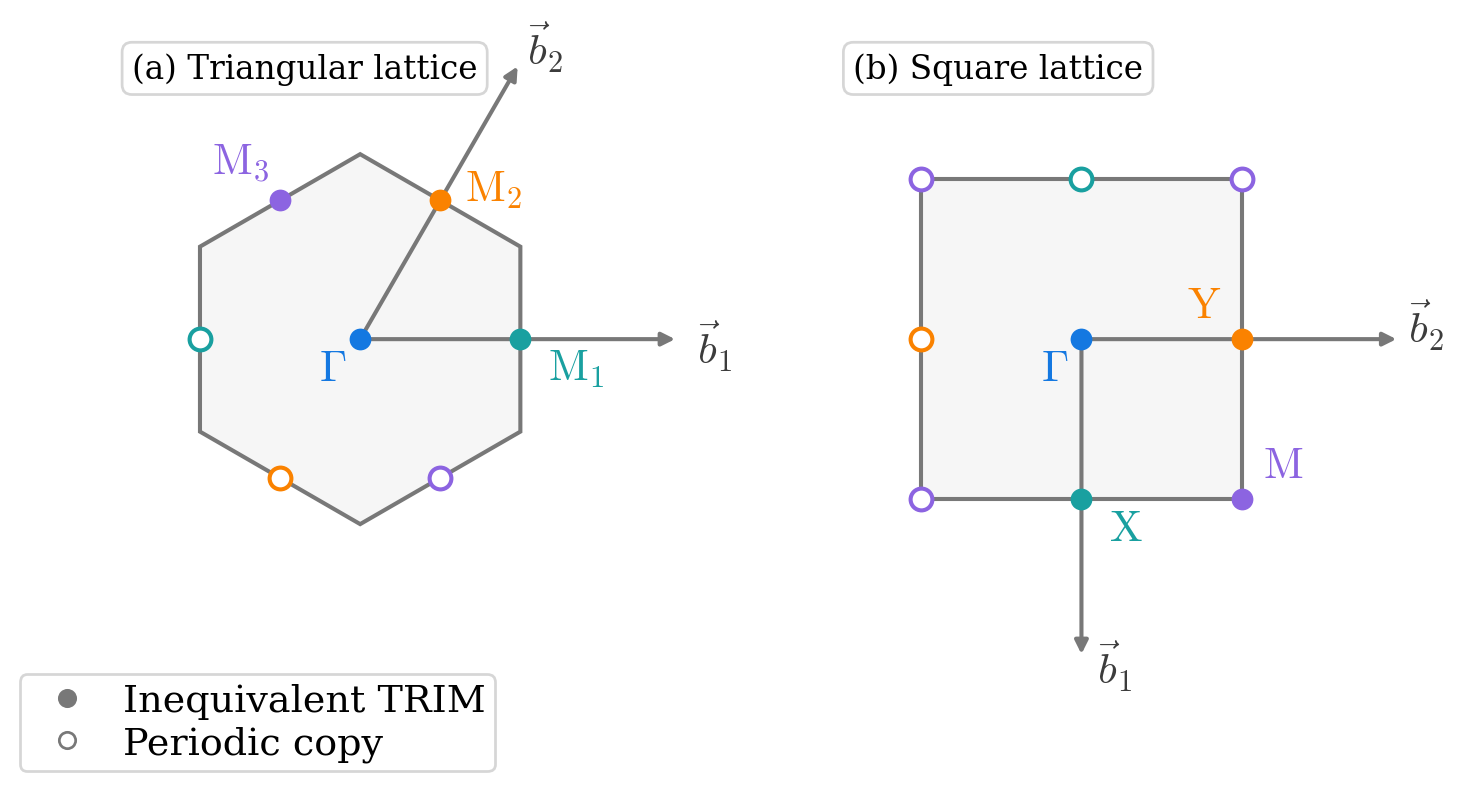

In [3]:
## reciprocal lattices
triangular_basis = np.array([[1., .5], [0., np.sqrt(3)/2]])
triangular_points = np.array([[0., 0.], [.5, 0.],
                              [.25, np.sqrt(3)/4], [-.25, np.sqrt(3)/4]])
triangular_copies = [(i, -triangular_points[i]) for i in (1, 2, 3)]

R = np.array([[0., 1.], [-1., 0.]])  # clockwise 90 degree rotation
rot = lambda x: np.asarray(x) @ R.T

square_basis = R @ np.eye(2)
square_points = rot([[0., 0.], [.5, 0.], [0., .5], [.5, .5]])
square_copies = [(1, rot([[-.5, 0.]])[0]), (2, rot([[0., -.5]])[0]),
                 (3, rot([[-.5, .5]])[0]), (3, rot([[-.5, -.5]])[0]),
                 (3, rot([[.5, -.5]])[0])]

## first Brillouin zones
angles = np.deg2rad(30 + 60*np.arange(6))
hexagon = np.column_stack((np.cos(angles), np.sin(angles))) / np.sqrt(3)
square = rot([[-.5, -.5], [.5, -.5], [.5, .5], [-.5, .5]])
tab_style = dict(boxstyle="round", facecolor="white", alpha=.8,
                 edgecolor=plt.rcParams["legend.edgecolor"])

layouts = [
    ("(a) Triangular lattice", triangular_basis, hexagon,
     triangular_points, triangular_copies,
     [r"$\Gamma$", r"$\mathrm{M}_1$", r"$\mathrm{M}_2$", r"$\mathrm{M}_3$"],
     [(-15, -15), (10, -15), (9, 0), (-25, 10)]),
    ("(b) Square lattice", square_basis, square,
     square_points, square_copies,
     [r"$\Gamma$", r"$\mathrm{X}$", r"$\mathrm{Y}$", r"$\mathrm{M}$"],
     [(-15, -15), (10, -15), (-20, 8), (8, 8)])]

## layout
fig, axes = plt.subplots(1, 2, figsize=trim_size, dpi=dpi, layout="none")
fig.subplots_adjust(left=.02, right=.98, bottom=.13, top=.98, wspace=-.08)

for ax, (title, basis, polygon, points, copies, names, offsets) in zip(axes, layouts):
    ax.set(aspect="equal", xlim=(-.78, 1.15), ylim=(-1.08, 1.00))
    ax.set_axis_off()
    ax.set_title(title, fontsize=subtitle, loc="left", x=.035, y=.95, pad=0,
                 va="top", bbox=tab_style, zorder=10)
    ax.add_patch(Polygon(polygon, closed=True, facecolor=".965",
                         edgecolor=grey, lw=line_width, zorder=0))

    for j, vector in enumerate(basis.T):
        ax.annotate("", xy=vector, xytext=(0, 0), zorder=1,
                    arrowprops=dict(arrowstyle="-|>", color=grey, lw=line_width))
        shift = [.05, -.02] if j == 0 else [.02, .045]
        ax.text(*(vector + shift), rf"$\vec{{b}}_{j+1}$", fontsize=label,
                va="center", ha="left", color=dark_grey)

    for original, point in copies:
        ax.scatter(*point, s=64, fc="white", ec=colors[original], lw=line_width, zorder=4)
    for point, color, name, offset in zip(points, colors, names, offsets):
        ax.scatter(*point, s=64, color=color, lw=0, zorder=5)
        ax.annotate(name, xy=point, xytext=offset, textcoords="offset points",
                    fontsize=label, color=color, zorder=6)

## vertical compact legend
legend_handles = [
    Line2D([], [], marker="o", ls="None", color=grey, markerfacecolor=grey,
           markersize=6, label="Inequivalent TRIM"),
    Line2D([], [], marker="o", ls="None", color=grey, markerfacecolor="white",
           markersize=6, label="Periodic copy")]

fig.legend(handles=legend_handles, loc="lower left", bbox_to_anchor=(.015, .02),
           ncols=1, frameon=True, fancybox=True,
           borderpad=.25, labelspacing=.15, handletextpad=.45, borderaxespad=0)

fig.savefig(output_directory / "4.2_trim.pdf", metadata={"CreationDate": None})
plt.show()
plt.close(fig)